In [1]:
import pandas as pd
df =pd.read_csv("train_1.csv",encoding="utf-8") 

df[['specific_name', 'lang_domain', 'access_type', 'access_origin']] = \
    df['Page'].str.rsplit('_', n=3, expand=True)

df[['language', 'domain']] = \
    df['lang_domain'].str.split('.', n=1, expand=True)



In [2]:
# !pip install ftfy

In [3]:
from ftfy import fix_text
df["name_fixed"] = df["specific_name"].astype(str).apply(fix_text)

In [4]:

df[['Page', 'specific_name','name_fixed',
       'lang_domain', 'access_type', 'access_origin', 'language', 'domain']].sample(1000).to_csv("pages_dump.csv", index=False)

## Embed titles with a small model
- We store resutls in pkl file as we dont want to do embeddings unnecessarily
- We will redo it only if Cached embeddings do not match current titles.

In [6]:
# pip install sentence-transformers scikit-learn hdbscan
import numpy as np
from sentence_transformers import SentenceTransformer
import os
import pickle
from pathlib import Path

titles = df["name_fixed"].astype(str).tolist()


cache_path = Path("title_embeddings.pkl")

if cache_path.exists():
    with cache_path.open("rb") as f:
        cache = pickle.load(f)
    X = cache["X"]
    # (optional safety) ensure cache matches current titles
    if cache.get("titles") != titles:
        raise ValueError("Cached embeddings do not match current titles. Delete the cache file and rerun.")
else:
    embedder = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    X = embedder.encode(
        titles,
        batch_size=256,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    X = np.asarray(X, dtype=np.float32)

    with cache_path.open("wb") as f:
        pickle.dump({"X": X, "titles": titles}, f, protocol=pickle.HIGHEST_PROTOCOL)

Batches:   0%|          | 0/567 [00:00<?, ?it/s]

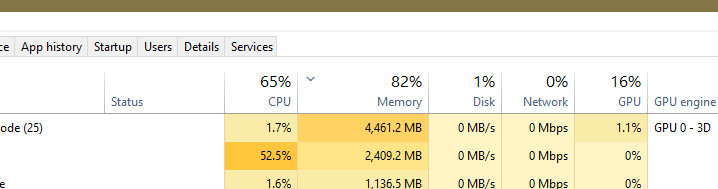

In [7]:
print("a")

a


## Step 2) Cluster titles into “major categories”
- We want to cluster these vectors so each page gets a cat_id (cluster label)
- We will use HDBSCAN (auto number of clusters)
- We store resutls in pkl file as we dont want to do hdbscan unnecessarily
- We will redo it only if X changes (hash differs) or we change any clustering/PCA parameter in PARAMS.

In [8]:
from pathlib import Path
import pickle, hashlib

import numpy as np
from sklearn.decomposition import PCA
import hdbscan

def hash_array(a: np.ndarray) -> str:
    """
    Robust fingerprint for X. This reads all bytes of X once (O(size of X)).
    If X is huge and this is too slow, tell me and I’ll give a faster (but less strict) hash.
    """
    a = np.ascontiguousarray(a)
    h = hashlib.sha256()
    h.update(str(a.shape).encode())
    h.update(a.dtype.str.encode())
    h.update(a.tobytes())
    return h.hexdigest()

# X is already float32 + normalized from sentence-transformers
X32 = np.asarray(X, dtype=np.float32)

# ---- params you consider part of the "same run" ----
PARAMS = {
    "pca_n_components": 50,
    "pca_random_state": 0,
    "min_cluster_size": 200,
    "min_samples": 20,
    "metric": "euclidean",
    "approx_min_span_tree": True,
}

cache_path = Path("hdbscan_results.pkl")
x_hash = hash_array(X32)

need_recompute = True
if cache_path.exists():
    with cache_path.open("rb") as f:
        cache = pickle.load(f)

    if cache.get("x_hash") == x_hash and cache.get("params") == PARAMS:
        labels = cache["labels"]
        Xp = cache.get("Xp")  # optional
        need_recompute = False

if need_recompute:
    # PCA
    pca = PCA(n_components=PARAMS["pca_n_components"], random_state=PARAMS["pca_random_state"])
    Xp = pca.fit_transform(X32).astype(np.float32)

    # HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=PARAMS["min_cluster_size"],
        min_samples=PARAMS["min_samples"],
        metric=PARAMS["metric"],
        core_dist_n_jobs=-1,
        approx_min_span_tree=PARAMS["approx_min_span_tree"],
    )
    labels = clusterer.fit_predict(Xp)

    with cache_path.open("wb") as f:
        pickle.dump(
            {"labels": labels, "Xp": Xp, "x_hash": x_hash, "params": PARAMS},
            f,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [23]:
n_clusters = labels.max() + 1
print(f"Number of clusters (excluding noise): {n_clusters}")

Number of clusters (excluding noise): 23


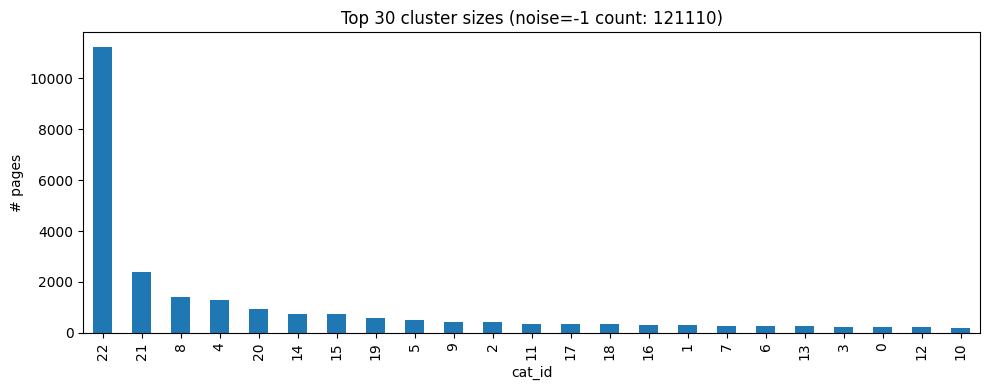

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Map the HDBScan back to our dataframe
df["cat_id"] = labels

vc = df["cat_id"].value_counts()
noise = int(vc.get(-1, 0))
vc_no_noise = vc.drop(index=-1, errors="ignore")

plt.figure(figsize=(10,4))
vc_no_noise.head(30).plot(kind="bar")
plt.title(f"Top 30 cluster sizes (noise=-1 count: {noise})")
plt.ylabel("# pages")
plt.tight_layout()
plt.show()

**2D scatter plot via UMAP (best visual intuition)**

Project embeddings to 2D with UMAP, then color by cat_id.

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap.

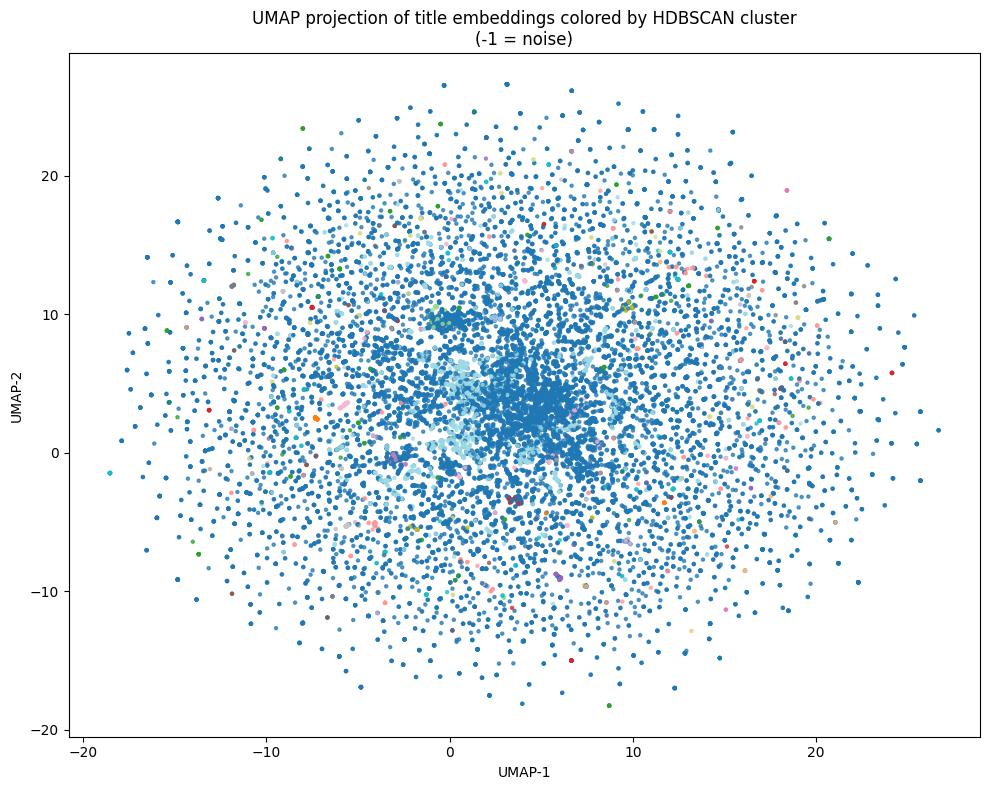

In [14]:
# pip install umap-learn
import numpy as np
import umap
import matplotlib.pyplot as plt

X_emb = X  # your embeddings array (n_pages, dim)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
X2 = reducer.fit_transform(X_emb)

labels = df["cat_id"].to_numpy()

# plot only a subsample if huge
rng = np.random.default_rng(0)
n = len(labels)
idx = rng.choice(n, size=min(20000, n), replace=False)

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    X2[idx, 0], X2[idx, 1],
    c=np.where(labels[idx] == -1, -1, labels[idx]),
    s=5, alpha=0.7, cmap="tab20"
)
plt.title("UMAP projection of title embeddings colored by HDBSCAN cluster\n(-1 = noise)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

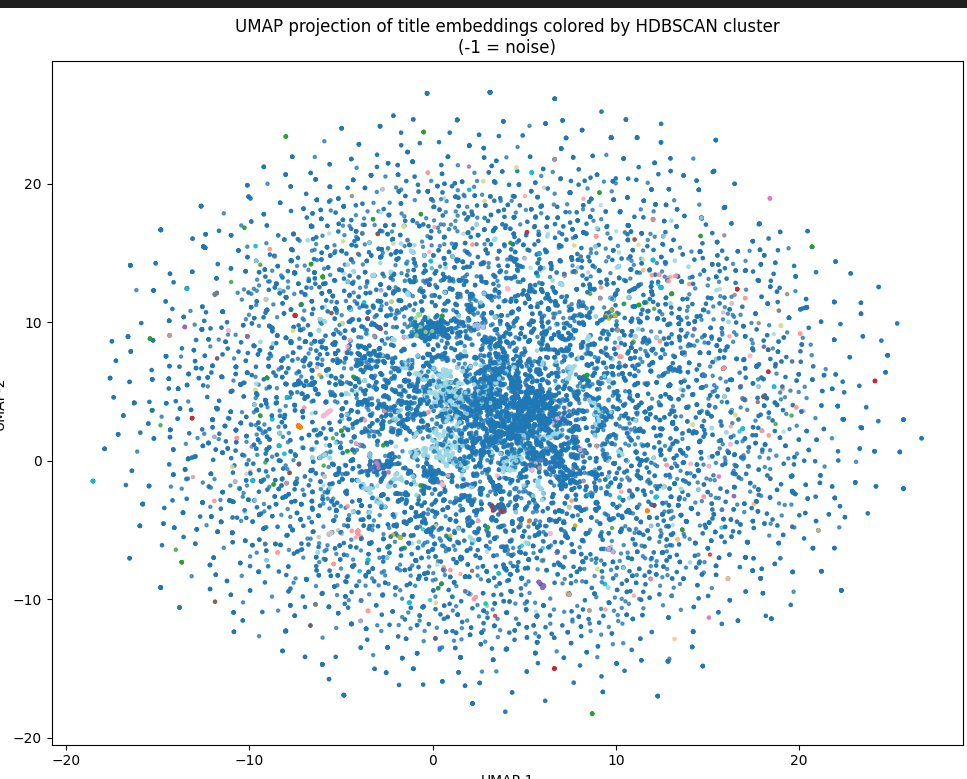

##  See only clusters, remove outliers

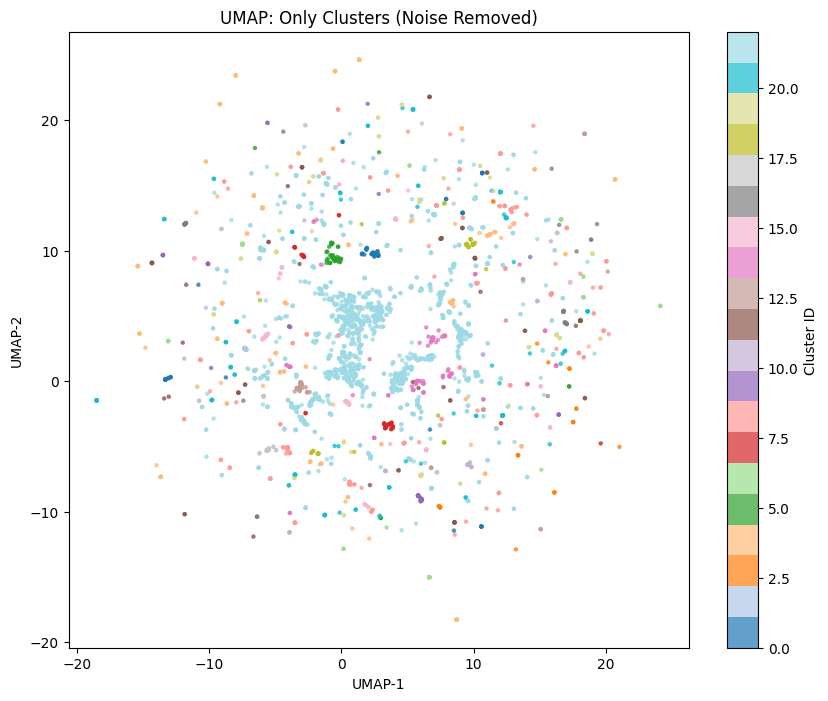

In [24]:
# 1. Create a mask for points that are NOT noise
mask = labels[idx] != -1

# 2. Filter the UMAP coordinates and labels using that mask
X_clusters = X2[idx][mask]
labels_clusters = labels[idx][mask]

plt.figure(figsize=(10, 8))
sc = plt.scatter(
    X_clusters[:, 0], 
    X_clusters[:, 1],
    c=labels_clusters,  # Only cluster labels here
    s=5, 
    alpha=0.7, 
    cmap="tab20"
)
plt.colorbar(sc, label="Cluster ID")
plt.title("UMAP: Only Clusters (Noise Removed)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.show()

### HDBSCAN condensed tree + cluster persistence (most “HDBSCAN-native”)

This visualizes how clusters form as the density threshold changes.

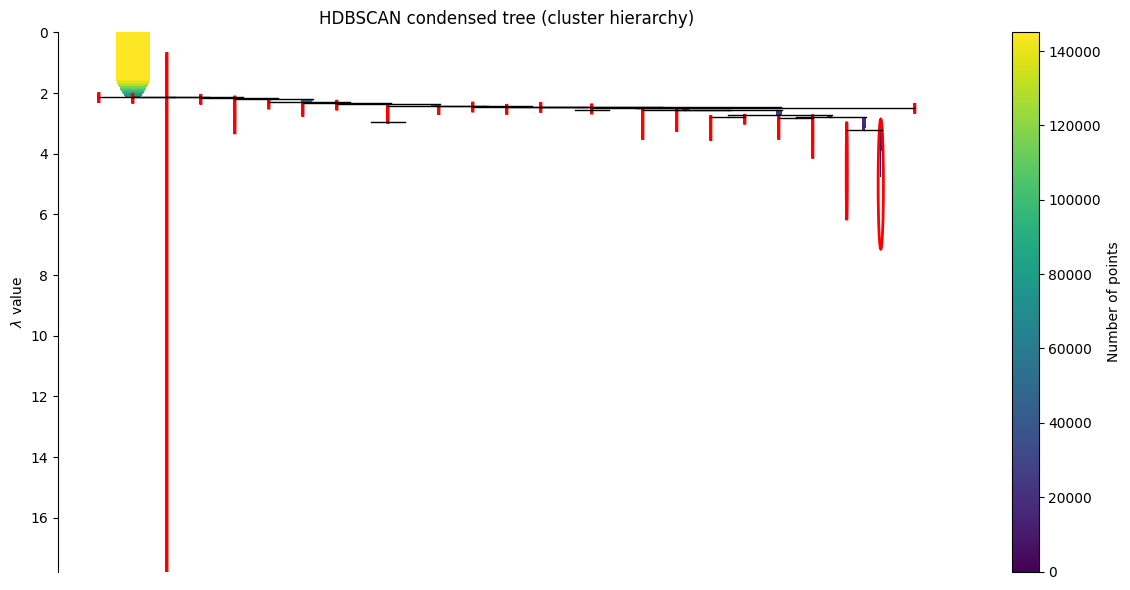

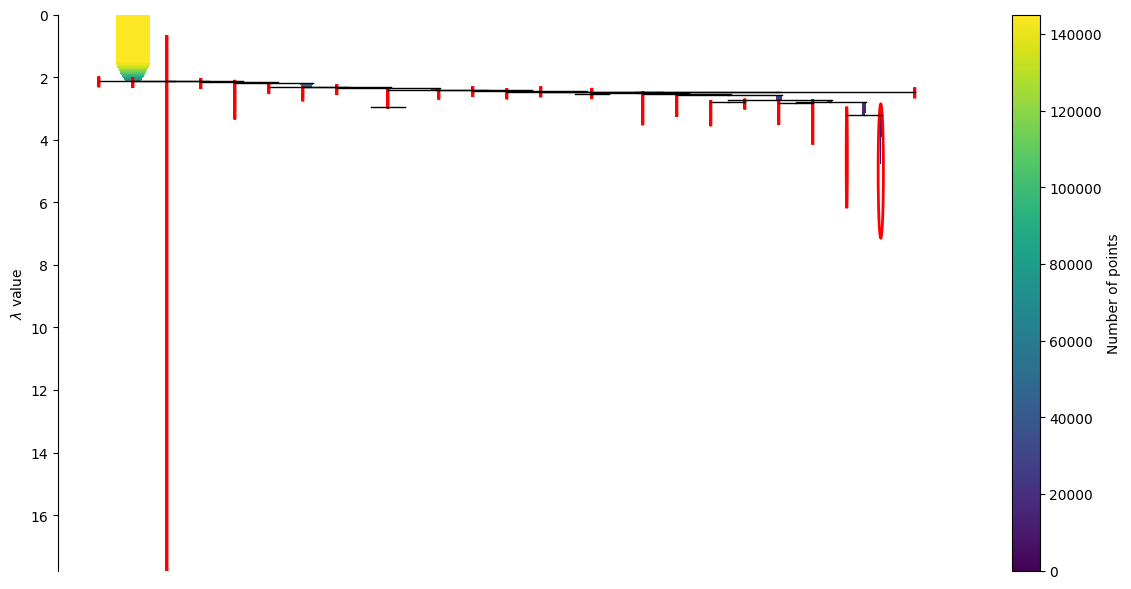

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# after: clusterer = hdbscan.HDBSCAN(...).fit(X)
plt.figure(figsize=(12, 6))
clusterer.condensed_tree_.plot(select_clusters=True)
plt.title("HDBSCAN condensed tree (cluster hierarchy)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette("tab20"))
plt.tight_layout()
plt.show()

**Inspect clusters by printing example titles (best sanity check)**

In [17]:
def show_cluster_examples(df, cluster_id, n=20):
    ex = df.loc[df["cat_id"] == cluster_id, "name_fixed"].sample(min(n, (df["cat_id"] == cluster_id).sum()), random_state=0)
    return ex.tolist()

# pick a cluster
cid = int(df["cat_id"].value_counts().drop(index=-1, errors="ignore").index[0])
print("Cluster", cid, "examples:")
print("\n".join(show_cluster_examples(df, cid, n=25)))

Cluster 22 examples:
中川梨絵
坂本ですが?
金瑟琪
井山裕太
優香
李宗伟
涼宮ハルヒの憂鬱_(アニメ)
同盟鶼鰈
Авианесущий_крейсер
藤沢周平
中村七之助_(2代目)
Фреско,_Жак
篠原信一
庵野秀明
田中邦衛
张翰_(中国演员)
スクール☆ウォーズ
韓石圭
もんじゅ
橋本環奈
彼岸
福原かれん
メガマウス
藤島泰輔
吳思賢_(藝人)


## Step 3) Pick representative titles per cluster (for labeling)

### What we do
For each cluster (e.g., cluster 12), we select a small set of page titles that are the “most typical” examples of that cluster—usually the titles closest to the cluster’s centroid in embedding space.

### Why we do it
Clusters are just integers (`cat_id = 12`) with no meaning on their own. To understand what a cluster represents, you need to **look at examples**.

But clusters can contain hundreds or thousands of pages; showing all titles is noisy and too much to read. So we choose “representative” titles that:
- are highly central/typical
- summarize the theme of that cluster

These representatives are later fed to an LLM (or to you) to name the cluster.

### Why “closest to centroid” makes sense
If embeddings capture semantic similarity, then:
- points near the centroid are the “core” meaning of the cluster
- points far from the centroid are edge cases / mixed pages

So the closest-to-centroid titles give a clean snapshot of the cluster’s topic.

---


In [19]:
from sklearn.metrics.pairwise import cosine_distances

def cluster_representatives(df, X, cat_col="cat_id", n=20):
    reps = {}
    for cid, idx in df.groupby(cat_col).groups.items():
        if cid == -1:
            continue
        idx = np.array(list(idx))
        Xi = X[idx]
        centroid = Xi.mean(axis=0, keepdims=True)
        d = cosine_distances(Xi, centroid).reshape(-1)
        best = idx[np.argsort(d)[:n]]
        reps[int(cid)] = df.loc[best, "name_fixed"].tolist()
    return reps

reps = cluster_representatives(df, X, "cat_id", n=25)
list(reps.items())[:1]  # preview

[(0,
  ['Гарри_Поттер_(серия_фильмов)',
   'Гарри_Поттер_(серия_фильмов)',
   'Гарри_Поттер_(серия_фильмов)',
   'Гарри_Поттер_(серия_фильмов)',
   'Harry_Potter_(films)',
   'Гарри_Поттер',
   'Гарри_Поттер',
   'Гарри_Поттер',
   'Гарри_Поттер',
   'Harry_Potter_(serie_cinematográfica)',
   'Harry_Potter_(serie_cinematográfica)',
   'Harry_Potter_(serie_cinematográfica)',
   'Harry_Potter_(serie_cinematográfica)',
   'Harry_Potter_(série_de_films)',
   'Harry_Potter_(série_de_films)',
   'Harry_Potter_(série_de_films)',
   'Harry_Potter_(série_de_films)',
   'Harry_Potter_(film_series)',
   'Harry_Potter_(film_series)',
   'Harry_Potter_(film_series)',
   'Harry_Potter_(film_series)',
   'Гарри_Поттер_и_Проклятое_дитя',
   'Гарри_Поттер_и_Проклятое_дитя',
   'Гарри_Поттер_и_Проклятое_дитя',
   'Гарри_Поттер_и_Проклятое_дитя'])]


## Step 4) Use a small LLM to name each cluster (few calls)

### What we do
For each cluster:
- Provide the LLM with the representative titles (e.g., 20–30 titles).
- Ask it to output:
  - a short **category name** (2–5 words)
  - a short **description** (1 sentence)

So cluster 12 might become something like:
- “Football players”
- “Biographies of professional footballers and related pages”

### Why we do it
Clustering gives you groups but no human-readable label. The LLM is being used as a **cluster labeler**, not as a per-page classifier.

This is important because it:
- reduces cost (you label, say, 50 clusters instead of 100k pages)
- improves consistency (a stable mapping from `cat_id → label`)
- gives you interpretable segments for analysis and modeling

### Output artifact you keep
You store a mapping like:

```json
{
  "12": {"name": "Football players", "desc": "..."},
  "13": {"name": "Pop music", "desc": "..."}
}
```

This becomes part of your pipeline and can be versioned.

---



In [26]:
from openai import OpenAI
from dotenv import load_dotenv
import os

# Load environment variables once at the top
load_dotenv()

def query_gemini_openai(prompt: str, model: str = "gemini-flash-lite-latest") -> str:
    """
    Queries Google Gemini using the OpenAI-compatible library.
    
    Args:
        prompt (str): The user's question.
        model (str): The model ID to use (default: gemini-flash-lite-latest) as it has max quota !
        
    Returns:
        str: The content of the response.
    """
    
    # 1. efficient key retrieval
    api_key = os.getenv('GEMINI_API_KEY')
    if not api_key:
        raise ValueError("❌ Error: GEMINI_API_KEY not found in .env file")

    # 2. Setup Client with Google's specific Base URL
    # Note: We create the client inside to ensure fresh connection settings, 
    # but for high-volume loops, you might instantiate this outside the function.
    client = OpenAI(
        api_key=api_key,
        base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
    )

    try:
        # 3. Make the call
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "user", "content": prompt}
            ],
        )
        
        # 4. Return clean text
        return response.choices[0].message.content

    except Exception as e:
        return f"❌ API Error: {str(e)}"

# --- Example Usage ---
if __name__ == "__main__":
    
    # Test 1: Standard Query
    answer = query_gemini_openai("What is the capital of India?")
    print(f"Answer: {answer}")
    
    # # Test 2: Using a different model 
    # answer_lite = query_gemini_openai("Explain Quantum Physics in one line", model="gemini-2.5-flash")
    # print(f"\nLite Answer: {answer_lite}")
    # answer_lite = query_gemini_openai("Explain India in 5 lines", model="gemini-flash-latest")
    # print(f"\nLite Answer: {answer_lite}")
    

Answer: The capital of India is **New Delhi**.


In [ ]:


def make_cluster_prompt(titles):
    bullet_list = "\n".join(f"- {t}" for t in titles[:25])
    return f"""
You are labeling clusters of Wikipedia page titles into broad categories for time-series modeling.
Given these titles, return:
1) category_name (2-5 words)
2) short_description (1 sentence)

Titles:
{bullet_list}
""".strip()

## Step 5) Categorize a new page at inference time (routing)

### What we do
When a user provides a new page:
1) Extract its title from the raw `Page` string.
2) Embed the title using the same embedding model.
3) Assign it to a cluster by comparing to cluster “representations” you saved (commonly centroids):
   - compute similarity of the new embedding to each cluster centroid
   - pick the closest centroid → `cat_id`

Now you have:
- `language` (from metadata)
- `cat_id` (from title embedding)

and you can route to the appropriate forecasting model, e.g.:
- model key = `(language, cat_id)`  
or `(language, access_type, access_origin, cat_id)` if you want.

### Why we do it
Clustering itself is not an “online classifier.” You need a deterministic, fast rule for assigning a new sample to an existing category set.

Using centroids is:
- fast (just cosine similarity to a small matrix)
- stable (same input → same cluster)
- doesn’t require re-running clustering every time

### Handling “unknown/uncertain” pages
You can use the similarity score:
- if max similarity is low → treat as “other/unknown” and use a fallback SARIMAX model (or an “other” cluster)

---



In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# precompute centroids for clusters (excluding noise)
centroids = {}
for cid in sorted(df["cat_id"].unique()):
    if cid == -1:
        continue
    idx = df.index[df["cat_id"] == cid].to_numpy()
    centroids[cid] = X[idx].mean(axis=0)

centroid_ids = np.array(list(centroids.keys()))
centroid_mat = np.stack([centroids[c] for c in centroid_ids]).astype(np.float32)

def categorize_page(page: str):
    title = extract_wiki_title(page)
    v = embedder.encode([title], normalize_embeddings=True).astype(np.float32)
    sims = cosine_similarity(v, centroid_mat).reshape(-1)
    best = int(centroid_ids[np.argmax(sims)])
    return {
        "title": title,
        "cat_id": best,
        "cat_label": cluster_names.get(best, f"cluster_{best}"),
        "similarity": float(np.max(sims))
    }

# example
# categorize_page('1989_(Taylor_Swift_album).en.wikipedia.org_desktop_all-agents')

## Step 6 (implied next step): train models per segment
Once every page is tagged with a category:
- group pages by `(language, category)` (or whatever segmentation)
- fit a SARIMAX per segment (or per page within a segment, depending on your design)
- evaluate forecast accuracy

---

## The overall reason for steps 3–5
Clustering + LLM labeling + centroid assignment is a common pattern to create a **new categorical variable** from messy text:

- Step 2 finds structure automatically.
- Step 3 makes it inspectable.
- Step 4 makes it interpretable.
- Step 5 makes it usable in production.

If you tell me roughly how many pages you have and how many “major categories” you want (e.g., 20 vs 200), I can recommend good `min_cluster_size` (HDBSCAN) or `k` (KMeans), and a good confidence threshold for “unknown.”